# OASIS INFOBYTE Internship

## Task 1: Exploratory Data Analysis (EDA) on Retail Sales Dataset

**Name:** Natasha Bhartiya

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import Libraries

The required Python libraries were imported successfully for data analysis and visualization.

In [2]:
# Load Dataset
df = pd.read_csv("retail_sales_dataset.csv")

## Dataset Loaded

The retail sales dataset was loaded successfully. The first five rows provide an overview of the dataset.

In [3]:
# Display First 5 Rows
print("="*50)
print("FIRST 5 ROWS")
print("="*50)
print(df.head())


FIRST 5 ROWS
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [4]:
# Dataset Information
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
df.info()


DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


## Dataset Information

The dataset contains 1000 records with appropriate data types.

In [5]:
# Shape
print("\n" + "="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)


DATASET SHAPE
(1000, 9)


## Dataset Shape

The dataset contains 1000 rows and 9 columns.

In [6]:
# Missing Values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())



MISSING VALUES
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


## Missing Values

No missing values were found in the dataset.

In [7]:
# Statistical Summary
print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print(df.describe())



STATISTICAL SUMMARY
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000


## Statistical Summary

The summary statistics provide insights into numerical columns such as Age, Quantity, Price per Unit, and Total Amount.

In [20]:
# Date Format Convert
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")

## Date Conversion

The Date column was converted to datetime format. Month and Quarter columns were created for time-based analysis.

In [9]:
# Month Column
df["Month"] = df["Date"].dt.month_name()

In [10]:
# Quarterly Column
df["Quarter"] = df["Date"].dt.quarter

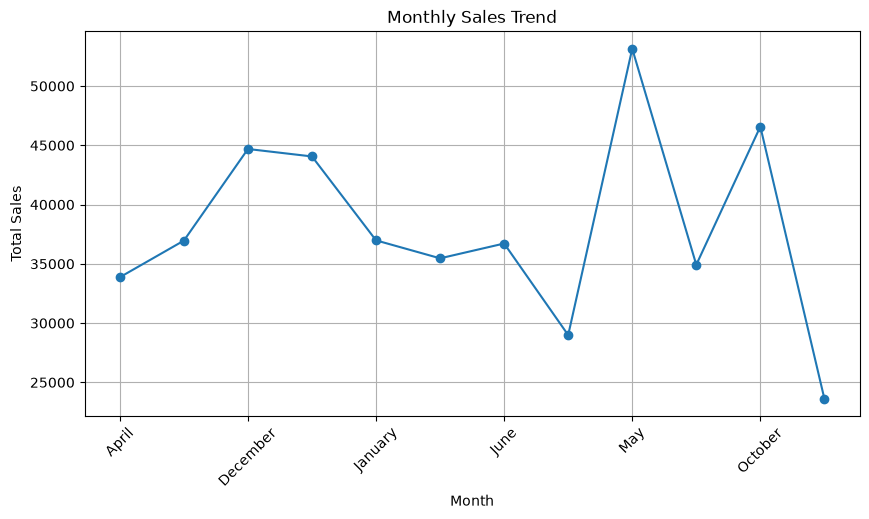

In [11]:
# Monthly Sales Trend
monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()



## Monthly Sales Trend

The monthly sales trend shows how sales vary across different months of the year.

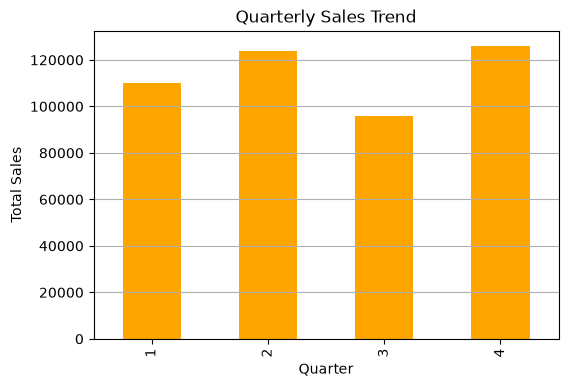

In [12]:
# Quarterly Sales Trend
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(6,4))
quarterly_sales.plot(kind="bar", color="orange")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(axis="y")
plt.show()

## Quarterly Sales Trend

Quarterly analysis helps compare sales performance across the four quarters of the year.

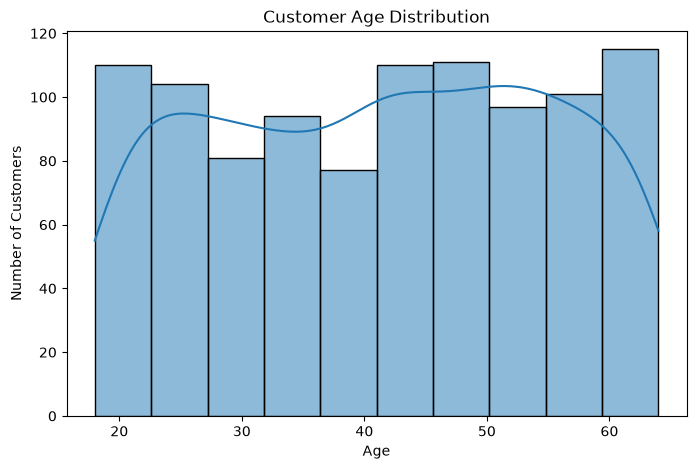

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

## Customer Age Distribution - Observation

The customer age distribution shows that the dataset contains customers from different age groups. Most customers belong to the middle-age group, indicating a diverse customer base.

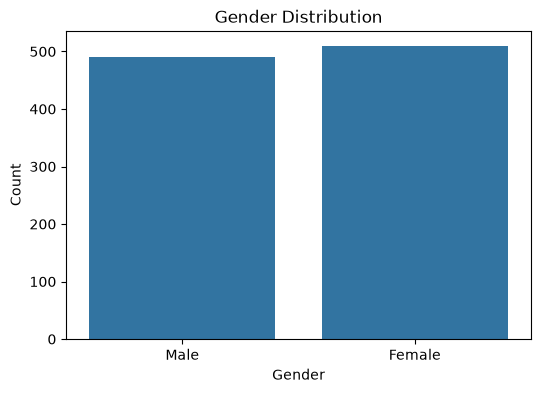

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

## Observation

The dataset contains both male and female customers. This helps analyze customer purchasing behavior based on gender.

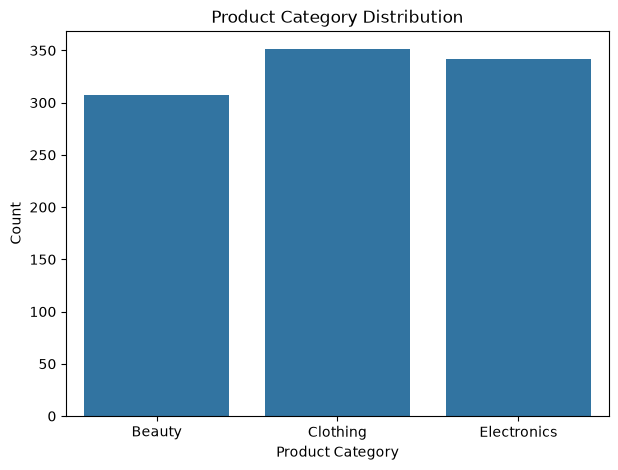

In [15]:
# Product Category Distribution
plt.figure(figsize=(7,5))
sns.countplot(x="Product Category", data=df)

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Count")

plt.show()

## Observation

The chart shows how products are distributed across different categories such as Beauty, Clothing, and Electronics.

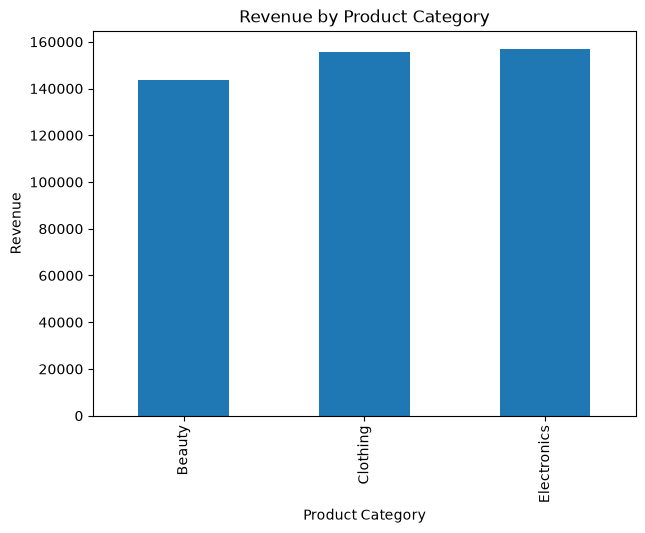

In [16]:
# Revenue by Product Category
category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(7,5))
category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.show()

## Observation

Revenue varies across product categories. Some categories generate higher sales than others.

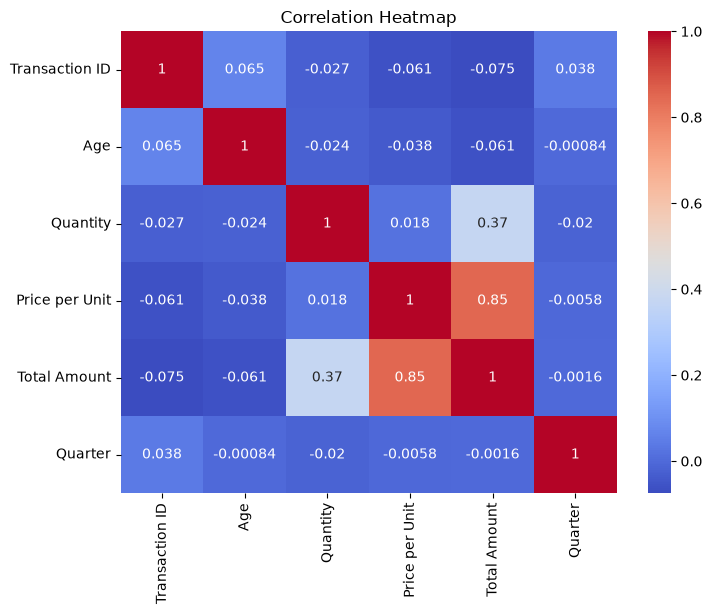

In [17]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## Observation

The heatmap shows the relationship between numerical variables such as Age, Quantity, Price per Unit, and Total Amount.

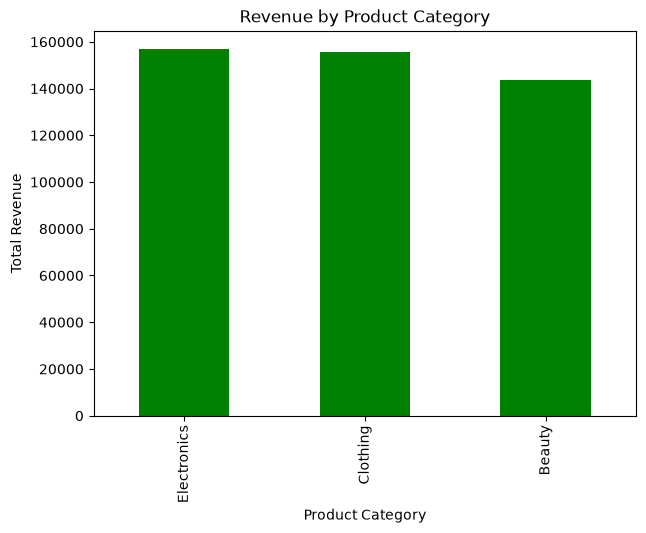

In [18]:
# Top 10 Best Selling Products
top_products = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
top_products.plot(kind="bar", color="green")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

## Observation

The chart shows which product categories generate the highest revenue.

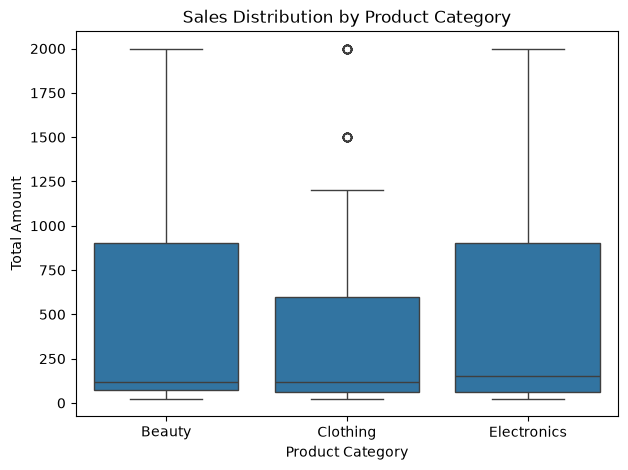

In [19]:
# Additional Visualization
plt.figure(figsize=(7,5))

sns.boxplot(x="Product Category", y="Total Amount", data=df)

plt.title("Sales Distribution by Product Category")

plt.show()

## Observation

The boxplot compares the sales distribution across different product categories and helps identify variations and outliers.

# Conclusion

This Exploratory Data Analysis (EDA) was performed on the Retail Sales Dataset to understand customer behavior and sales patterns.

Key findings:
- Sales vary across different months and quarters.
- The dataset contains customers from different age groups.
- Product categories contribute differently to total revenue.
- The correlation analysis provides insights into relationships between numerical features.

Overall, this analysis helps businesses understand customer trends and make better decisions.

# Business Recommendations

1. Increase stock and marketing efforts for high-revenue product categories.

2. Introduce promotional offers during months with lower sales to improve revenue.

3. Design targeted marketing campaigns for different customer age groups and genders to increase customer engagement.